<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/MLP_mnist_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import the libraries



In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

## Get the Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


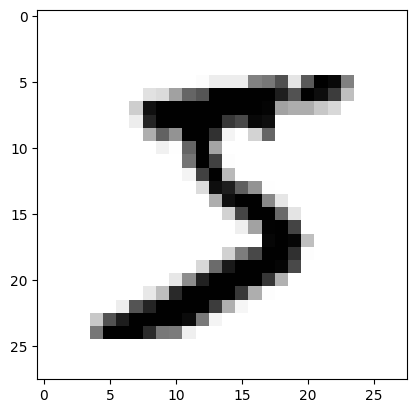

In [ ]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

plt.imshow(train_images[0], cmap=plt.cm.binary)

## Define the Model

In [ ]:
model = keras.Sequential(
  [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation = tf.nn.relu),
    keras.layers.Dense(128, activation = tf.nn.relu),
    keras.layers.Dense(10, activation = tf.nn.softmax)
  ]
)

model.summary()

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

model.fit(train_images, train_labels, epochs = 5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8199 - loss: 4.1414
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9242 - loss: 0.4020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9436 - loss: 0.2333
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9548 - loss: 0.1715
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9618 - loss: 0.1373


## Evaluate the model

In [ ]:
train_loss, train_acc = model.evaluate(train_images, train_labels)
print(f"Train accuracy: {train_acc}")
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9660 - loss: 0.1091
Train accuracy: 0.9662500023841858
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9506 - loss: 0.1825
Test accuracy: 0.9569000005722046


## Predict on test images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


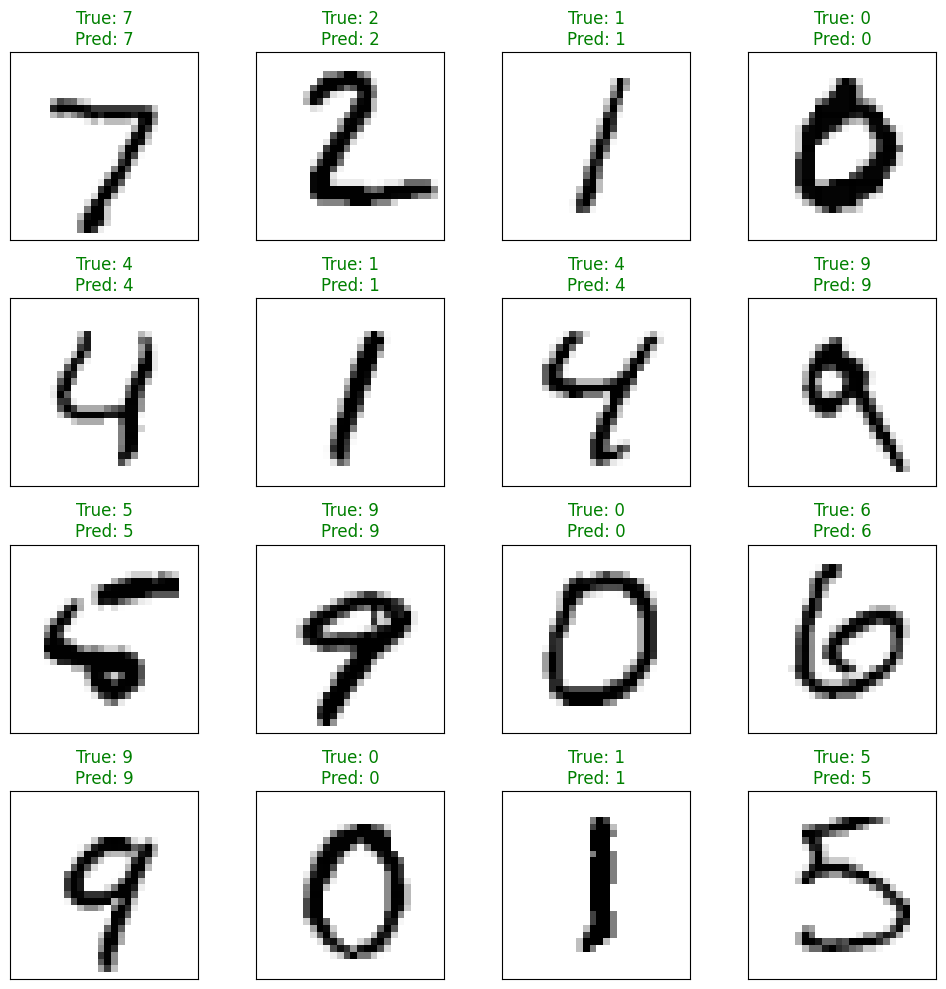

In [ ]:
predictions = model.predict(test_images)
'''
for i in range(5):
  plt.imshow(test_images[i]y)
  plt.show()
  print(f"Predicted: {predictions[i].argmax()}")
  print(f"Actual: {test_labels[i]}")
'''
# Visualize the results
fig = plt.figure(figsize=(10, 10))
for i in range(min(16, len(test_images))): # Display up to 16 images
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(test_images[i], cmap = plt.cm.binary)
    color = "green" if predictions[i].argmax() == test_labels[i] else "red"
    ax.set_title(f"True: {test_labels[i]}\nPred: {predictions[i].argmax()}", color=color)

plt.tight_layout()
plt.show()